# Setup

**Google Colab Instructions**
1. Create shortcut to `ECE542` shared folder on your `MyDrive` folder.
    1. Go to [ECE542](https://drive.google.com/drive/folders/1pZEix9DfPbXUyLbO_JhGi1fhZKBc5_77?usp=drive_link)
    2. Right click folder name (ECE542 at the top) > Organize > Add shortcut
    3. Click "All locations" tab > My Drive

1. Upload `utils.py` from the repo to your session's content folder.

1. Run the cell below to grant permissions and install packages.

1. Now everything else should run smoothly!

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# !pip install torch_geometric
# !pip install optuna

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
import joblib
import optuna

from utils import *

## Load data

In [3]:
# Define paths and file names
# For Colab use
# root_path = 'drive/MyDrive/ECE542/'
# For local use
root_path = 'data/'
data_path = root_path + '7194372/'
tf_filenames_dict = {
    'maize'     : 'Zma_TF_list.txt',
    'rice'      : 'Osj_TF_list.txt',
    'sorghum'   : 'Sbi_TF_list.txt'
}

Load expression data

In [4]:
# Load and format expression data
exp_data = pd.read_csv(f"{data_path}Input_data-2022-001/orthogroup_expression/"
                       "zma_osa_sbi_ortho_hai_expr_all.tsv", sep='\t')
exp_data.columns = [col.lower().replace('.','_') for col in exp_data.columns]
exp_data.head()

,gene_id,mean_leaf_section_1,mean_leaf_section_2,mean_leaf_section_3,mean_leaf_section_4,mean_leaf_section_6,mean_leaf_section_7,mean_leaf_section_8,mean_leaf_section_9,mean_leaf_section_10,...,srr6257228_mean,srr6257231_mean,srr8401514_mean,srr9202997_mean,srr9202998_mean,srr9203000_mean,srr9203001_mean,srr9203002_mean,srr9203003_mean,srr9203005_mean
0,ORTHO04M000001,4.546497,6.520382,6.253503,6.826752,6.745223,3.363057,5.000000,4.141401,4.249045,...,2.605618,1.835184,1.601559,2.432007,1.622150,2.686271,1.748511,2.181920,2.756412,2.326934
1,ORTHO04M000002,5.568790,10.509554,11.924204,7.954140,3.438217,0.000000,1.582803,1.537580,1.446497,...,10.177549,3.879458,0.796495,6.654203,1.350818,4.058331,6.377811,3.781891,2.106601,6.723717
2,ORTHO04M000003,5.755689,4.791018,4.871257,5.071257,4.532335,0.161677,3.382036,2.816168,3.359880,...,28.256274,29.906009,3.003803,9.677179,7.787140,10.327200,13.166616,9.940935,9.422623,13.480669
3,ORTHO04M000004,5.931737,7.356886,9.832934,9.923952,6.170659,0.000000,3.388623,2.559281,2.589820,...,5.598559,7.510683,2.290947,3.690457,2.634284,4.460366,4.990626,3.275099,3.170542,5.966543
4,ORTHO04M000005,22.267045,31.086364,33.167045,26.302273,12.117045,2.005682,7.471591,6.215909,5.164773,...,8.677945,10.664965,1.042287,10.677949,1.715857,7.845614,13.432008,10.941222,4.615420,18.174727


Load TF data

In [5]:
# Load TF data from PlantDB
tf_data_dict = {}
all_tf_gene_ids = []
for crop, filename in tf_filenames_dict.items():
    # Load and format data
    temp_df = pd.read_csv(f'{data_path}{filename}', sep='\t')
    temp_df.columns = [col.lower().replace('.','_') for col in temp_df.columns]

    # Add data to dictionary and gene IDs to list
    tf_data_dict[crop] = temp_df
    all_tf_gene_ids += tf_data_dict[crop]['gene_id'].tolist()

# Get a set of unique TF gene IDs
all_tf_gene_ids = set(all_tf_gene_ids)
print(len(all_tf_gene_ids))

6010


Load mapping data

In [6]:
# Load and format ortholog mapping data
map_data = pd.read_csv(f'{data_path}Input_data-2022-001/orthogroups/'
                       'maize_outward/orthos_maize_outward.tsv', sep='\t')
map_data.columns = [col.lower().replace('#','') for col in map_data.columns]
map_data['og'] = map_data.og.apply(lambda x: f"ORTHO04M{x[2:].zfill(6)}")

# Get orthologous gene IDs
tf_ortho_ids = (
    map_data.query('orthologous_gene in @all_tf_gene_ids')
    ['og'].unique().tolist()
)
print(len(tf_ortho_ids))

1591


# Baseline Model

## Explanation

Baseline model is a Partial Least Squares Regression Model

- **target** ($X_{nonTF}$): gene expression matrix (GEM) with orthogroups not assciated with transcription factors (TFs).

- **predictor** ($X_{TF}$): GEM with only TF orthogroups.

- **Goal**: predict col. of $X_{nonTF}$ with a combination from $X_{TF}$.

Other notes:
- Transforms space of predictors in $X_{TF}$ to orthogonal variables (linear, independent).
- Used PLSA algorithm where Y and $X_{TF}$ variables spaces are modeled simultaneaously.
- They used corss-validation to find optimal number of componenets
- Model evaluation: spearman rank correlation
- Results: predicted expression profila of all genes across all experiments and compared to observed abundances.

## PLS regression model

In [ ]:
X_all = (
    exp_data.query('gene_id in @tf_ortho_ids')
    .set_index('gene_id').T.copy().fillna(0)
)
Y_all = (
    exp_data.query('gene_id not in @tf_ortho_ids')
    .set_index('gene_id').T.copy().fillna(0)
)

# Implement the 80:20 Train-Test Split across experiments
X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all,
                                                    test_size=0.20,
                                                    random_state=42)

In [ ]:
# components = 3
pls = PLSRegression(n_components=3)

# Fit the model: Using the TF "Control Center" to predict the "Factory" output
pls.fit(X_all, Y_all)

# This gives you the 'estimated' expression data for target genes
Y_pred = pls.predict(X_all)

# Calculate how well the TFs predict each target gene (R-squared)
score = pls.score(X_all, Y_all)
print(f"Total variance explained: {score:.4f}")

Total variance explained: 0.2304


In [ ]:
# Ensure Y is a numpy array for consistent operations with Y_pred
Y_true = Y_all.to_numpy()

# Initialize a list to store Spearman correlation coefficients for each target gene
spearman_correlations = []

# Iterate through each target gene (column) to calculate correlation
# Y_pred and Y_true have shape (n_samples, n_features)
for i in range(Y_true.shape[1]):
    # Calculate Spearman correlation for the i-th target gene
    # between its actual values and predicted values across all samples
    corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])
    spearman_correlations.append(corr)

# Convert the list of correlations to a pandas Series for easier analysis
spearman_series = pd.Series(spearman_correlations, index=Y_all.columns)

# Display descriptive statistics of the correlations
print("Descriptive Statistics of Spearman Correlations for Target Genes:")
display(spearman_series.describe())

# Optionally, display the first few correlations
print("\nTop 10 Spearman Correlations:")
display(spearman_series.nlargest(10))

print("\nBottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):")
display(spearman_series.nsmallest(10))

mean_rho = np.nanmean(spearman_series)
print(f"Mean Spearman Correlation: {mean_rho:.2f}")

Descriptive Statistics of Spearman Correlations for Target Genes:


count    17893.000000
mean         0.473699
std          0.292592
min         -0.392400
25%          0.178542
50%          0.499115
75%          0.747398
max          0.962975
dtype: float64


Top 10 Spearman Correlations:


gene_id
ORTHO04M000688    0.962975
ORTHO04M002110    0.959836
ORTHO04M003276    0.957315
ORTHO04M001953    0.952293
ORTHO04M001323    0.951650
ORTHO04M003472    0.951615
ORTHO04M004052    0.951573
ORTHO04M000592    0.951126
ORTHO04M006083    0.950831
ORTHO04M002236    0.950744
dtype: float64


Bottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):


gene_id
ORTHO04M008117   -0.392400
ORTHO04M011036   -0.347512
ORTHO04M010514   -0.335474
ORTHO04M000289   -0.324260
ORTHO04M010880   -0.293288
ORTHO04M011091   -0.280535
ORTHO04M001722   -0.279296
ORTHO04M008985   -0.252235
ORTHO04M010302   -0.248333
ORTHO04M009502   -0.244556
dtype: float64

Mean Spearman Correlation: 0.47


## Random Forest

Train RF model

In [ ]:
# # Memory-Optimized Initialization
# rf_model = RandomForestRegressor(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1,
#     # Reduces feature evaluation from 558 to ~24 per split
#     max_features='sqrt',
#     # Each tree uses 70% of rows, saving RAM during sorting
#     max_samples=0.7,
#     # Prevents trees from growing deep enough to exhaust memory
#     max_depth=20,
#     # Stops splits early if they don't have enough data
#     min_samples_leaf=5,
#     # Required for max_samples to work
#     bootstrap=True
# )

# print("Training Optimized Random Forest Regressor...")
# rf_model.fit(X_train, Y_train)
# print('Done!')

Save/load RF model

In [ ]:
model_filename = f'{root_path}/rf_model_noGAE.joblib'

# Save model
# print(f"Saving model to {model_filename}...")
# joblib.dump(rf_model, model_filename)
# print("Model saved successfully!")

# Load model
rf_model = joblib.load(model_filename)

d:\anaconda3\envs\sci\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\anaconda3\envs\sci\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# Ensure Y is a numpy array for consistent operations with Y_pred
Y_pred = rf_model.predict(X_all)
Y_true = Y_all.to_numpy()

# Initialize a list to store Spearman correlation coefficients for each target gene
spearman_correlations = []

# Iterate through each target gene (column) to calculate correlation
# Y_pred and Y_true have shape (n_samples, n_features)
for i in range(Y_true.shape[1]):
    # Calculate Spearman correlation for the i-th target gene
    # between its actual values and predicted values across all samples
    corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])
    spearman_correlations.append(corr)

# Convert the list of correlations to a pandas Series for easier analysis
spearman_series = pd.Series(spearman_correlations, index=Y_all.columns)

# Display descriptive statistics of the correlations
print("Descriptive Statistics of Spearman Correlations for Target Genes:")
display(spearman_series.describe())

# Optionally, display the first few correlations
print("\nTop 10 Spearman Correlations:")
display(spearman_series.nlargest(10))

print("\nBottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):")
display(spearman_series.nsmallest(10))

mean_rho = np.nanmean(spearman_series)
print(f"Mean Spearman Correlation: {mean_rho:.2f}")

C:\Users\alexi\AppData\Local\Temp\ipykernel_16020\1210771720.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])


Descriptive Statistics of Spearman Correlations for Target Genes:


count    17723.000000
mean         0.614500
std          0.293056
min         -0.108895
25%          0.333767
50%          0.749741
75%          0.870069
max          0.964583
dtype: float64


Top 10 Spearman Correlations:


gene_id
ORTHO04M000995    0.964583
ORTHO04M001365    0.959385
ORTHO04M003474    0.958542
ORTHO04M002784    0.957670
ORTHO04M001476    0.957378
ORTHO04M001656    0.957161
ORTHO04M000404    0.956123
ORTHO04M003472    0.955194
ORTHO04M000658    0.954992
ORTHO04M007538    0.954663
dtype: float64


Bottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):


gene_id
ORTHO04M011611   -0.108895
ORTHO04M008117   -0.073203
ORTHO04M002033   -0.056511
Zm00001d000567   -0.020976
ORTHO04M008603   -0.014154
ORTHO04M005981   -0.006425
ORTHO04M206076    0.011694
ORTHO04M205905    0.013255
Zm00001d052571    0.013949
Zm00001d037508    0.013994
dtype: float64

Mean Spearman Correlation: 0.61


# Graph Autoencoder (GAE)

## Data prep

Only use Arabidopsis map data

In [7]:
# Create a dictionary to map orthologous gene IDs to OG
map_data_ath = map_data.query('orthologous_species == "ath"').copy()
# at_to_ortho_dict = map_data_ath.set_index('orthologous_gene')['og'].to_dict()
map_data_ath = map_data_ath[['og', 'orthologous_gene']]

Load iGRN network

In [8]:
# Load iGRN network
net_data = pd.read_csv(f"{root_path}Data_file1_iGRN_supervised_network_support.txt",
                       sep='\t', header=None, usecols=[0, 1, 2])
net_data.columns = ['Source_AT', 'Target_AT', 'Weight']

# Threshold the network (like stated in paper)
net_data = net_data.query('Weight >= 0.9').copy()

# Map the network to Ortholog Space
# NOTE: using merge for one-to-many mapping (one AT can map to many OGs)
net_data = net_data.merge(
    map_data_ath,
    left_on='Source_AT',
    right_on='orthologous_gene',
    how='inner'
)
net_data = (net_data.rename(columns={'og': 'Source_Ortho'})
            .drop(columns=['orthologous_gene']))
net_data = net_data.merge(
    map_data_ath,
    left_on='Target_AT',
    right_on='orthologous_gene',
    how='inner'
)
net_data = (net_data.rename(columns={'og': 'Target_Ortho'})
            .drop(columns=['orthologous_gene']))

# Build PyTorch Geometric Edge Index
gene_to_index = {gene_id: i for i, gene_id in enumerate(exp_data['gene_id'])}

# Map to indices
net_data['Source_Idx'] = net_data['Source_Ortho'].map(gene_to_index)
net_data['Target_Idx'] = net_data['Target_Ortho'].map(gene_to_index)

# Drop any edges where a node isn't in the expression data
net_data = net_data.dropna(subset=['Source_Idx', 'Target_Idx'])

print(net_data.shape)
print(net_data.head())

(8574, 7)
   Source_AT  Target_AT    Weight    Source_Ortho    Target_Ortho  Source_Idx  \
0  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M002736       464.0   
1  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M004007       464.0   
2  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M009921       464.0   
5  AT4G36920  AT3G61470  0.985894  ORTHO04M008323  ORTHO04M002736      7931.0   
6  AT4G36920  AT3G61470  0.985894  ORTHO04M008323  ORTHO04M004007      7931.0   

   Target_Idx  
0      2619.0  
1      3826.0  
2      9163.0  
5      2619.0  
6      3826.0  


Create edge

In [9]:
# Convert mapped string IDs to integer row indices
source_indices = net_data['Source_Idx'].astype(int).values
target_indices = net_data['Target_Idx'].astype(int).values

# Create the 2D edge_index tensor
edge_index = torch.tensor(np.array([source_indices, target_indices]),
                          dtype=torch.long)
print(f"Constructed edge_index with shape: {edge_index.shape}")

Constructed edge_index with shape: torch.Size([2, 8574])


Split data into train and test

In [10]:
# Fill missing values with 0
clean_exp_data = np.log1p(exp_data.fillna(0.0).set_index('gene_id'))

# Identify the experiment columns
experiment_cols = clean_exp_data.columns.tolist()

# Perform an 70:30 split on the column names (experiments)
train_exps, temp_exps = train_test_split(experiment_cols, test_size=0.3,
                                         random_state=42)
val_exps, test_exps = train_test_split(temp_exps, test_size=0.5,
                                       random_state=42)

# Create a masked copy of the expression data for training
train_exp_data_masked = clean_exp_data.copy()
test_exp_data_masked = clean_exp_data.copy()

# Mask the validation and test experiments with 0.0 to prevent data leakage
train_exp_data_masked[val_exps + test_exps] = 0.0

# Scale the features using ONLY the masked training data
scaler = StandardScaler()
scaled_train_features = scaler.fit_transform(train_exp_data_masked)

# Convert to PyTorch Tensor
X_train_tensor = torch.tensor(scaled_train_features, dtype=torch.float32)

# 2. Put the scaled data back into a DataFrame so we can easily slice it by name
scaled_train_df = pd.DataFrame(
    scaled_train_features,
    index=clean_exp_data.index,
    columns=clean_exp_data.columns
)

# 3. Identify only the Target Genes (exclude the TFs)
target_genes = [g for g in clean_exp_data.index if g not in tf_ortho_ids]

# 4. Slice the DataFrame: Target Genes (rows) and ONLY Training Experiments (columns)
Y_train_df = scaled_train_df.loc[target_genes, train_exps]

# 5. Convert to PyTorch Tensor
Y_train_tensor = torch.tensor(Y_train_df.to_numpy(), dtype=torch.float32)

print(f"Masked Feature Tensor Shape (X_train_tensor): {X_train_tensor.shape}")
print(f"Number of Masked Test Experiments: {len(test_exps)}")

Masked Feature Tensor Shape (X_train_tensor): torch.Size([18449, 698])
Number of Masked Test Experiments: 105


## Training

Build model

In [11]:
# Initialize Model and Optimizer
in_channels = X_train_tensor.shape[1] # Number of expression experiments
out_channels = 128 # The size of the latent embedding space

# Instantiate the Graph Autoencoder
model = GAE(ShallowEncoder(in_channels, out_channels))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
X_train_tensor = X_train_tensor.to(device)
edge_index = edge_index.to(device)

Train

In [12]:
gae_model, gae_losses = train_gae(model, optimizer, X_train_tensor, edge_index,
                                  epochs=25)

Epoch: 001 | GAE Recon Loss: 16.6357
Epoch: 010 | GAE Recon Loss: 2.7487
Epoch: 020 | GAE Recon Loss: 1.6664


Loss graph

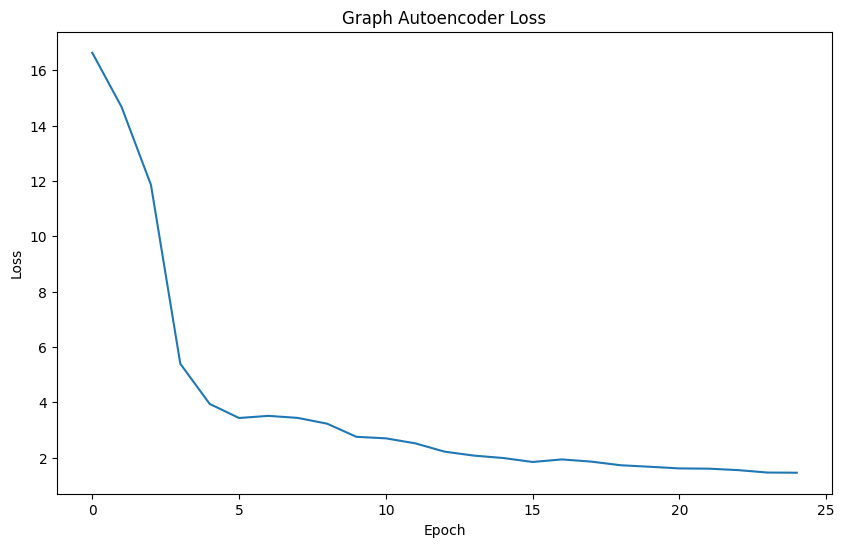

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(gae_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Graph Autoencoder Loss')
plt.show()

Once trained, generate the final embeddings (detached from the gradient graph)

In [14]:
gae_model.eval()
with torch.no_grad():
    Z_train = model.encode(X_train_tensor, edge_index).cpu().numpy()

# Multilayer Perceptron (MLP)

MLP for estimating gene expression

Split data

In [17]:
# 1. Get embeddings from GAE
Z_tensor = torch.tensor(Z_train, dtype=torch.float32).to(device)

# --- Prepare Unmasked Targets ---
# Transform the original clean_exp_data using the scaler fitted ONLY on the training data
true_scaled_features = scaler.transform(clean_exp_data)
true_scaled_df = pd.DataFrame(
    true_scaled_features, 
    index=clean_exp_data.index, 
    columns=clean_exp_data.columns
)

# 1. Get all targets mapped correctly
true_scaled_df = pd.DataFrame(true_scaled_features, index=clean_exp_data.index, columns=clean_exp_data.columns)

target_indices = [gene_to_index[g] for g in target_genes if g in gene_to_index]
mlp_inputs = Z_tensor[target_indices]
mlp_targets = torch.tensor(true_scaled_df.loc[target_genes].to_numpy(), dtype=torch.float32).to(device)

# 2. Split the ROWS (Genes) into 70% Train, 15% Val, 15% Test
X_temp, X_test, Y_temp, Y_test = train_test_split(
    mlp_inputs.cpu().numpy(), mlp_targets.cpu().numpy(), test_size=0.15, random_state=42
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.176, random_state=42 # 0.176 of 85% is ~15% of total
)

# Convert back to tensors
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)
Y_val = torch.tensor(Y_val, dtype=torch.float32).to(device)
Y_test = torch.tensor(Y_test, dtype=torch.float32).to(device)

## Training

In [25]:
# Initialize MLP
mlp_model = ExpressionMLP(
    input_dim=128,
    hidden_dim=256,
    output_dim=698
).to(device)

In [26]:
# Train the model
trained_mlp, train_loss, val_loss = train_mlp2(
    mlp_model, 
    X_train,
    Y_train,
    X_val,
    Y_val,
    epochs=80, 
    lr=0.002
)

Epoch: 001 | Train MSE: 2.0059 | Val MSE: 1.9509
Epoch: 020 | Train MSE: 0.8475 | Val MSE: 0.8044
Epoch: 040 | Train MSE: 0.6857 | Val MSE: 0.6739
Epoch: 060 | Train MSE: 0.6190 | Val MSE: 0.6064
Epoch: 080 | Train MSE: 0.4961 | Val MSE: 0.4798


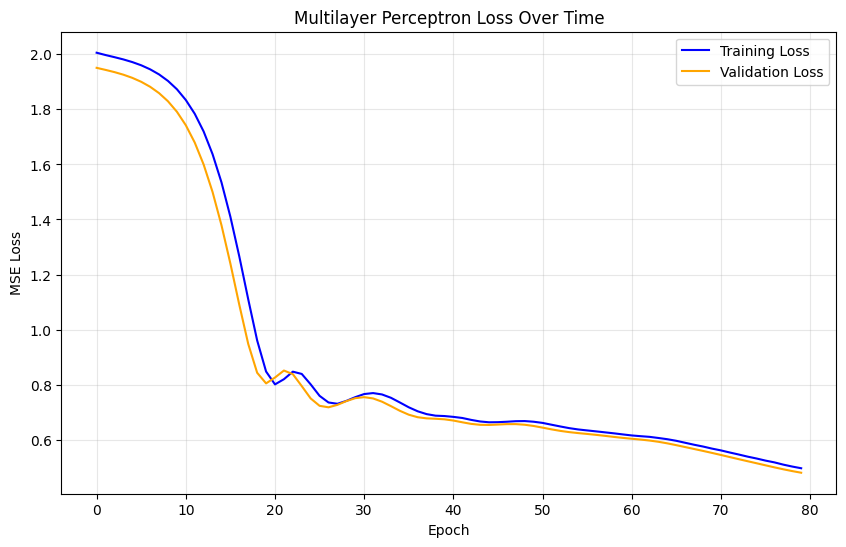

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Multilayer Perceptron Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluation

In [28]:
def get_mlp_results(mlp_model, X_train, Y_train, X_val, Y_val, X_test, Y_test, scaler):
    # 1. Set the model to evaluation mode
    mlp_model.eval()

    # 2. Generate predictions for ALL splits
    with torch.no_grad():
        train_predictions = mlp_model(X_train).cpu().numpy()
        val_predictions = mlp_model(X_val).cpu().numpy()
        test_predictions = mlp_model(X_test).cpu().numpy()

    # 3. Move targets to CPU
    train_targets = Y_train.cpu().numpy()
    val_targets = Y_val.cpu().numpy()
    test_targets = Y_test.cpu().numpy()

    # --- UNSCALING LOGIC ---
    # 4. Extract means and stds for ALL experiments from the scaler
    # Since predictions now have 698 columns, we use the full scaler arrays
    exp_means = scaler.mean_
    exp_stds = scaler.scale_

    # 5. Step A: Reverse the StandardScaler (Z-score -> Log-TPM)
    train_predictions_log = (train_predictions * exp_stds) + exp_means
    train_targets_log = (train_targets * exp_stds) + exp_means
    
    val_predictions_log = (val_predictions * exp_stds) + exp_means
    val_targets_log = (val_targets * exp_stds) + exp_means
    
    test_predictions_log = (test_predictions * exp_stds) + exp_means
    test_targets_log = (test_targets * exp_stds) + exp_means

    # 6. Step B: Reverse the Log-transformation (Log-TPM -> Raw TPM)
    train_predictions_tpm = np.expm1(train_predictions_log)
    train_targets_tpm = np.expm1(train_targets_log)
    
    val_predictions_tpm = np.expm1(val_predictions_log)
    val_targets_tpm = np.expm1(val_targets_log)
    
    test_predictions_tpm = np.expm1(test_predictions_log)
    test_targets_tpm = np.expm1(test_targets_log)

    # --- METRIC CALCULATION (Scaled space) ---
    train_mse = mean_squared_error(train_targets, train_predictions)
    val_mse = mean_squared_error(val_targets, val_predictions)
    test_mse = mean_squared_error(test_targets, test_predictions)
    
    train_rho, _ = spearmanr(train_targets.flatten(), train_predictions.flatten())
    val_rho, _ = spearmanr(val_targets.flatten(), val_predictions.flatten())
    test_rho, _ = spearmanr(test_targets.flatten(), test_predictions.flatten())

    # --- METRIC CALCULATION (Real Units: Raw TPM) ---
    train_mae_tpm = mean_absolute_error(train_targets_tpm, train_predictions_tpm)
    val_mae_tpm = mean_absolute_error(val_targets_tpm, val_predictions_tpm)
    test_mae_tpm = mean_absolute_error(test_targets_tpm, test_predictions_tpm)
    
    train_mse_tpm = mean_squared_error(train_targets_tpm, train_predictions_tpm)
    val_mse_tpm = mean_squared_error(val_targets_tpm, val_predictions_tpm)
    test_mse_tpm = mean_squared_error(test_targets_tpm, test_predictions_tpm)

    # 7. Construct the Results DataFrame
    results_df = pd.DataFrame({
        'Metric': ['MSE (Scaled)', 'MAE (TPM)', 'MSE (TPM)', 'Spearman Correlation'],
        'Train (Seen Genes)': [train_mse, train_mae_tpm, train_mse_tpm, train_rho],
        'Validation (Unseen Genes)': [val_mse, val_mae_tpm, val_mse_tpm, val_rho],
        'Test (Unseen Genes)': [test_mse, test_mae_tpm, test_mse_tpm, test_rho]
    })

    return results_df, (train_predictions_tpm, train_targets_tpm, 
                        val_predictions_tpm, val_targets_tpm,
                        test_predictions_tpm, test_targets_tpm)

In [29]:
results_df, tpm_data = get_mlp_results(
    trained_mlp, X_train, Y_train, X_val, Y_val, X_test, Y_test, scaler
)
(train_pred, train_tar, val_pred, val_tar, test_pred, test_tar) = tpm_data
print(results_df.round(4))

                 Metric  Train (Seen Genes)  Validation (Unseen Genes)  \
0          MSE (Scaled)              0.4854                     0.4798   
1             MAE (TPM)             17.3580                    16.0217   
2             MSE (TPM)          82327.0950                 59039.8800   
3  Spearman Correlation              0.8735                     0.8725   

   Test (Unseen Genes)  
0               0.4748  
1              16.9939  
2           41900.8120  
3               0.8722  


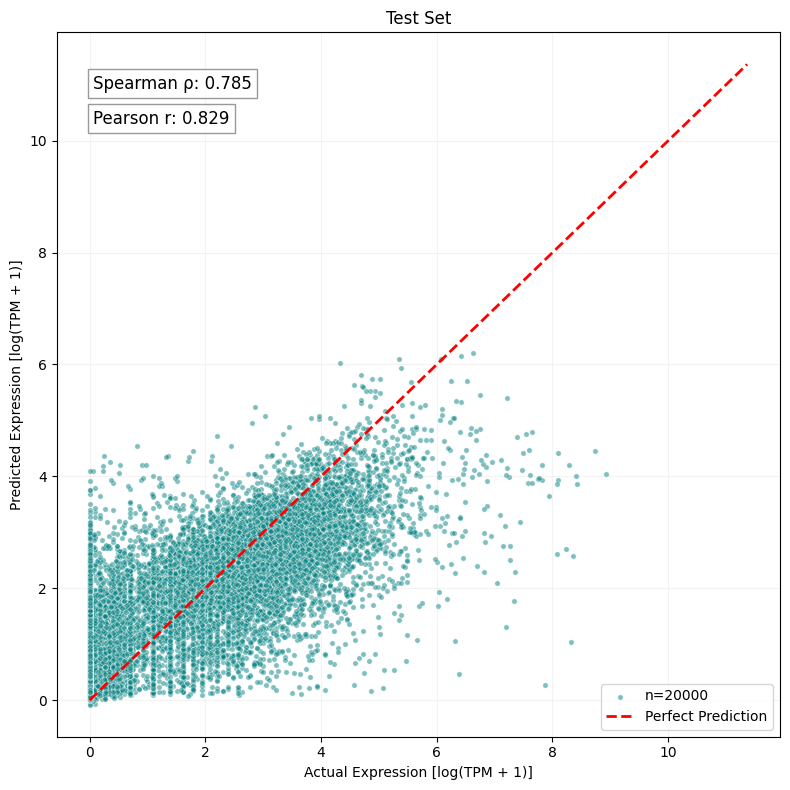

In [30]:
plot_expression_predictions(test_tar, test_pred, title='Test Set',
                            sample_size=20000)

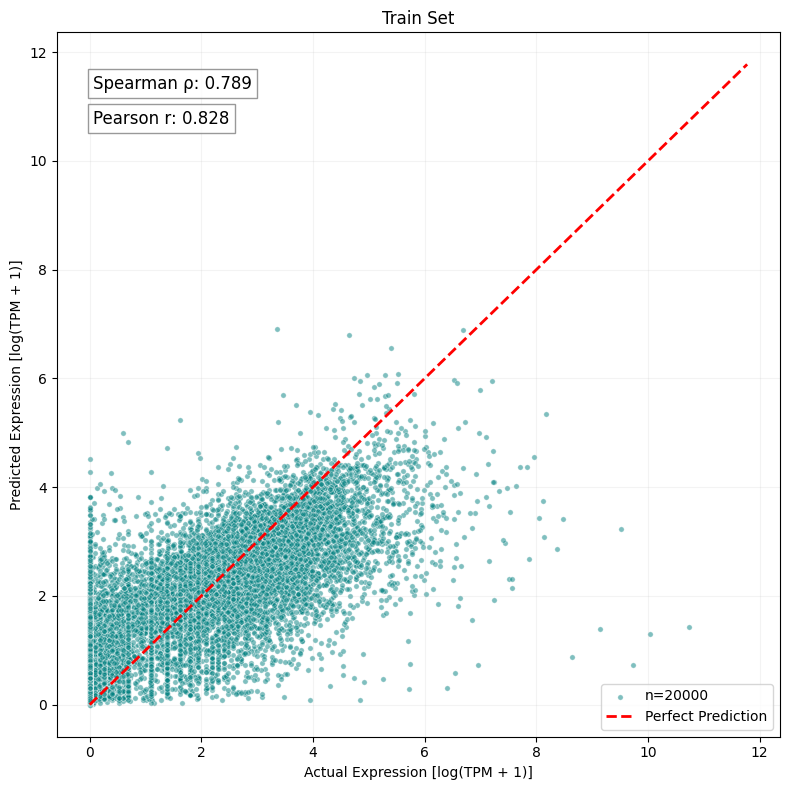

In [31]:
plot_expression_predictions(train_tar, train_pred, title='Train Set',
                            sample_size=20000)